# Figure 7 — inference-time mitigation on five characterized CIFAR-10 seeds

Renders `fig7.{pdf,png}`: 5 rows (memorized seeds) x 3 blocks (`Unguided` /
`FR` / `Bayesian FR`), each showing the generated image beside its nearest training image.

## Cost

Real 1000-step DDPM: 5 seeds x 3 conditions = 15 runs, ~150s each, budget ~40 minutes (Bayesian
is slowest, `B=256` draws/step). Cached per run, so re-styling never re-samples and tuning one
arm doesn't re-run the others. Set `DEVICE` first (`mps` here, `cpu` otherwise).

`PER_SEED` overrides `DEFAULTS` per seed (seed 13 starts guidance earlier, `window_lo=0.40`).

In [1]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO = os.path.abspath("../..")
sys.path.insert(0, os.path.join(REPO, "experiments", "cifar10"))
sys.path.insert(0, os.path.join(REPO, "src"))
sys.path.insert(0, os.path.join(REPO, "workshop_figures"))

from diffusers import UNet2DModel, DDPMScheduler
from cifar10_data import load_cifar10
from assess_memorization_cifar10 import nearest_neighbor_d1_d2
from guidance import driver, basic_fr, bayesian_fr
import wsstyle

# assess_memorization_cifar10 switches matplotlib to Agg on import; undo that here
%matplotlib inline

mpl_fs = 19
wsstyle.use_style(font_size=mpl_fs)

In [2]:
EXP = os.path.join(REPO, "experiments", "cifar10")
CACHE = os.path.join(REPO, "workshop_figures", "cache", "fig7_runs.pt")

config = {
    "device": os.environ.get("DEVICE", "cpu"),
    "pretrained_dir": os.path.join(EXP, "pretrained", "ddpm-cifar10-32"),
    "score_ckpt_path": os.path.join(EXP, "trained_data", "ddpm_finetuned.pt"),
    "single_sample_path": os.path.join(EXP, "checkpoints", "single_sample.pt"),
    "cifar10_data_dir": os.path.join(REPO, "data", "cifar-10-batches-py"),
    "finetune_seed": 0,
    "n_train": 1000,
    "mem_ratio_threshold": 1 / 2,
    "seeds": [9, 12, 13, 18, 19],
    "k_neighbors": 15,
    "ell": 1,
}

# DEFAULTS tuned in experiments/cifar10/02_fr_guidance.ipynb; PER_SEED overrides only what differs.
DEFAULTS = {"window_lo": 0.45, "window_hi": 1.0, "eta": 0.1, "q_target": 0.8}

PER_SEED = {
     9: {},
    12: {},
    13: {"window_lo": 0.40},   # re-collapses if guidance begins at 0.45
    18: {},
    19: {},
}

# alpha -> infinity recovers uniform-prior (plain FR); LARGER alpha = weaker bootstrap
DIRICHLET_ALPHA, B_BOOTSTRAP = 0.8, 256

METHODS = ["unguided", "basic", "bayesian"]
METHOD_LABELS = {"unguided": "Unguided", "basic": "FR", "bayesian": "Bayesian FR"}


def settings_for(seed):
    return {**DEFAULTS, **PER_SEED.get(seed, {})}


def _run_key(seed, method, st, alpha, B, k):
    """Settings taken explicitly, so a cache written under different settings can be re-keyed."""
    if method == "unguided":
        return f"unguided|seed={seed}"
    common = (f"seed={seed}|lo={st['window_lo']}|hi={st['window_hi']}"
              f"|eta={st['eta']}|qt={st['q_target']}|k={k}")
    if method == "basic":
        return f"basic|{common}"
    return f"bayesian|{common}|alpha={alpha}|B={B}"


def run_key(seed, method):
    """Cache key: every setting that changes the output. dirichlet_alpha/B only appear in
    the bayesian key, so retuning them leaves unguided/FR entries valid."""
    return _run_key(seed, method, settings_for(seed), DIRICHLET_ALPHA, B_BOOTSTRAP,
                    config["k_neighbors"])


def pack(x):
    return x.reshape(x.shape[0], -1)


def unpack(z):
    return z.reshape(z.shape[0], 3, 32, 32)


for s in config["seeds"]:
    print(f"seed {s:>3}: {settings_for(s)}")

seed   9: {'window_lo': 0.45, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8}
seed  12: {'window_lo': 0.45, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8}
seed  13: {'window_lo': 0.4, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8}
seed  18: {'window_lo': 0.45, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8}
seed  19: {'window_lo': 0.45, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8}


## Load the training subset, the finetuned model, and the characterized seeds

In [3]:
single_sample = torch.load(config["single_sample_path"], map_location="cpu", weights_only=False)
assert single_sample["device"] == config["device"], (
    f"candidates were generated on {single_sample['device']!r}, this notebook is on "
    f"{config['device']!r} -- set DEVICE to match or the seeds will not reproduce")

images, _ = load_cifar10(data_dir=config["cifar10_data_dir"], split="train")
rng = np.random.default_rng(config["finetune_seed"])
train_idx = rng.choice(len(images), size=config["n_train"], replace=False)
X_train = images[train_idx].to(config["device"])
X_train_flat = pack(X_train)
train_index = basic_fr.build_flat_index(X_train_flat)

net = UNet2DModel.from_pretrained(config["pretrained_dir"]).to(config["device"])
score_ckpt = torch.load(config["score_ckpt_path"], map_location=config["device"], weights_only=False)
net.load_state_dict(score_ckpt.get("model_ema", score_ckpt["model"]))
net.eval()
for p in net.parameters():
    p.requires_grad_(False)

scheduler = DDPMScheduler.from_pretrained(config["pretrained_dir"])
alphas_cumprod = scheduler.alphas_cumprod.to(config["device"])

_by_seed = {c["seed"]: c for c in single_sample["candidates"]}
missing = [s for s in config["seeds"] if s not in _by_seed]
assert not missing, f"seeds {missing} missing from {config['single_sample_path']}"


def select_seed(seed):
    """Rebind per-seed globals; scheduler.timesteps is shared mutable state."""
    global candidate, n_steps
    candidate = _by_seed[seed]
    n_steps = candidate["n_steps"]
    scheduler.set_timesteps(n_steps)
    return candidate


for s in config["seeds"]:
    c = _by_seed[s]
    print(f"  seed={s}  n_steps={c['n_steps']}  unguided ratio={c['ratio']:.3f}  "
          f"nn_train_idx={c['nn_train_idx']}")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


  seed=9  n_steps=1000  unguided ratio=0.208  nn_train_idx=458
  seed=12  n_steps=1000  unguided ratio=0.213  nn_train_idx=783
  seed=13  n_steps=1000  unguided ratio=0.308  nn_train_idx=595
  seed=18  n_steps=1000  unguided ratio=0.305  nn_train_idx=99
  seed=19  n_steps=1000  unguided ratio=0.234  nn_train_idx=881


## Sampler wiring and the two guidance energies

In [4]:
def make_wiring(generator):
    def denoise_to_y(z_t, t):
        x_t = unpack(z_t)
        eps_hat = net(x_t, t).sample
        a_t = alphas_cumprod[t]
        y = (x_t - (1 - a_t).sqrt() * eps_hat) / a_t.sqrt()
        return pack(y).clamp(-1, 1)

    def y_fn(z_t):
        return denoise_to_y(z_t, y_fn.t)

    def base_step_with_t(z_t, step_idx):
        t = scheduler.timesteps[step_idx - 1]
        y_fn.t = t
        x_t = unpack(z_t)
        eps_hat = net(x_t, t).sample
        return pack(scheduler.step(eps_hat, t, x_t, generator=generator).prev_sample)

    def sigma2_fn():
        return (1 - alphas_cumprod[y_fn.t]).expand(1)

    return y_fn, base_step_with_t, sigma2_fn


def make_energy_fn(method, sigma2_fn, q_target, generator=None):
    """basic and bayesian share retrieval and softmax temperature, so they differ only in
    how E/beta becomes a posterior -- a clean ablation of the prior."""
    def energy_fn(y):
        with torch.no_grad():
            neighbors, sq_d = basic_fr.ann_query(train_index, y, config["k_neighbors"])
        bf = basic_fr.beta_soft_for(sq_d, q_target)
        if method == "basic":
            I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2_fn(), beta_soft=bf)
        elif method == "bayesian":
            I, _, _ = bayesian_fr.fisher_rao_energy_bb(
                y, neighbors, sigma2_fn(), B=B_BOOTSTRAP,
                dirichlet_alpha=DIRICHLET_ALPHA, beta_soft=bf, generator=generator)
        else:
            raise ValueError(method)
        return I
    return energy_fn


def evaluate(x_final):
    d1, d2, nn_idx = nearest_neighbor_d1_d2(pack(x_final), X_train_flat)
    ratio = (d1 / d2).item()
    return {"d1": d1.item(), "d2": d2.item(), "ratio": ratio,
            "nn_idx": int(nn_idx.item()),
            "is_memorized": ratio < config["mem_ratio_threshold"]}


def run_condition(seed, method):
    """Unguided reuses the identical wiring/z_init, so the three arms are paired exactly."""
    st = settings_for(seed)
    gen = torch.Generator(device=config["device"]).manual_seed(seed)
    y_fn, base_step_with_t, sigma2_fn = make_wiring(gen)
    z_init = pack(torch.randn(1, 3, 32, 32, device=config["device"], generator=gen))

    if method == "unguided":
        z = z_init
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                z = base_step_with_t(z, step_idx)
    else:
        guidance_fn = driver.make_autograd_guidance_fn(
            y_fn, make_energy_fn(method, sigma2_fn, st["q_target"], generator=gen), target_range=None)
        z, _ = driver.guided_reverse_loop(
            z_init, n_steps, base_step_with_t, guidance_fn,
            progress_lo=st["window_lo"], progress_hi=st["window_hi"],
            ell=config["ell"], trust_region=st["eta"])

    x_final = unpack(z).clamp(-1, 1)
    return x_final.detach().cpu(), evaluate(x_final)

## Run the conditions that are not already cached

Cache is keyed per run (see `run_key`), so changing `DIRICHLET_ALPHA` only re-runs the 5
Bayesian runs, and changing a seed's `window_lo` only re-runs that seed's guided arms.
`FORCE` re-runs specific methods regardless of cache (use after changing sampling code).

In [5]:
FORCE = []          # e.g. ["bayesian"] to re-run that arm even when cached

store = {}
blob = torch.load(CACHE, weights_only=False) if os.path.exists(CACHE) else {}
store = blob.get("runs", {})

# migrate pre-keyed cache (flat "rows" payload) to per-run keys, if present
if "rows" in blob and not store:
    old_alpha = blob.get("bayesian", {}).get("dirichlet_alpha")
    old_B = blob.get("bayesian", {}).get("B")
    old_k = blob.get("config", {}).get("k_neighbors", config["k_neighbors"])
    for seed, r in blob["rows"].items():
        for method, rec in r["methods"].items():
            key = _run_key(seed, method, r["settings"], old_alpha, old_B, old_k)
            store[key] = {**rec, "seed": seed, "method": method,
                          "settings": r["settings"],
                          "alpha": old_alpha if method == "bayesian" else None}
    print(f"migrated {len(store)} runs from the pre-keyed cache "
          f"(bayesian entries keyed at alpha={old_alpha})")

if store:
    print(f"cache holds {len(store)} runs")

planned = [(seed, m) for seed in config["seeds"] for m in METHODS]
todo = [(s_, m) for s_, m in planned if run_key(s_, m) not in store or m in FORCE]
print(f"{len(planned) - len(todo)} reused, {len(todo)} to run")
print()

for seed, method in todo:
    select_seed(seed)
    t0 = time.time()
    x_final, stats = run_condition(seed, method)
    store[run_key(seed, method)] = {
        "seed": seed, "method": method, "x": x_final,
        "nn": X_train[stats["nn_idx"]].detach().cpu(), "stats": stats,
        "settings": settings_for(seed),
        "alpha": DIRICHLET_ALPHA if method == "bayesian" else None,
    }
    print(f"seed={seed:>3} {method:<9} ratio={stats['ratio']:.3f} "
          f"memorized={str(stats['is_memorized']):<5} nn={stats['nn_idx']:<4} "
          f"({time.time() - t0:.0f}s)")

if todo:
    torch.save({"runs": store}, CACHE)
    print()
    print("saved ->", CACHE)

payload = {"rows": {seed: {"settings": settings_for(seed),
                            "methods": {m: store[run_key(seed, m)] for m in METHODS}}
                     for seed in config["seeds"]}}

print()
print(f"caption numbers  (Bayesian FR: dirichlet_alpha={DIRICHLET_ALPHA}, B={B_BOOTSTRAP})")
for seed in config["seeds"]:
    r = payload["rows"][seed]
    bits = "  ".join(f"{m}: ratio={r['methods'][m]['stats']['ratio']:.3f} "
                     f"mem={r['methods'][m]['stats']['is_memorized']}" for m in METHODS)
    print(f"  seed {seed:>3} (window_lo={r['settings']['window_lo']}): {bits}")

cache holds 40 runs
15 reused, 0 to run


caption numbers  (Bayesian FR: dirichlet_alpha=0.8, B=256)
  seed   9 (window_lo=0.45): unguided: ratio=0.208 mem=True  basic: ratio=0.998 mem=False  bayesian: ratio=0.997 mem=False
  seed  12 (window_lo=0.45): unguided: ratio=0.213 mem=True  basic: ratio=1.000 mem=False  bayesian: ratio=0.998 mem=False
  seed  13 (window_lo=0.4): unguided: ratio=0.308 mem=True  basic: ratio=0.999 mem=False  bayesian: ratio=0.999 mem=False
  seed  18 (window_lo=0.45): unguided: ratio=0.305 mem=True  basic: ratio=0.999 mem=False  bayesian: ratio=0.999 mem=False
  seed  19 (window_lo=0.45): unguided: ratio=0.234 mem=True  basic: ratio=1.000 mem=False  bayesian: ratio=0.996 mem=False


## Render

Same house style as Figure 1: light rule grid, no legend (column titles carry the meaning),
row labels on the left, no hyperparameters in the figure. Nearest-training tiles get a lighter
frame than generated ones so the pairing reads without labels.

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig7.pdf', '/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig7.png']


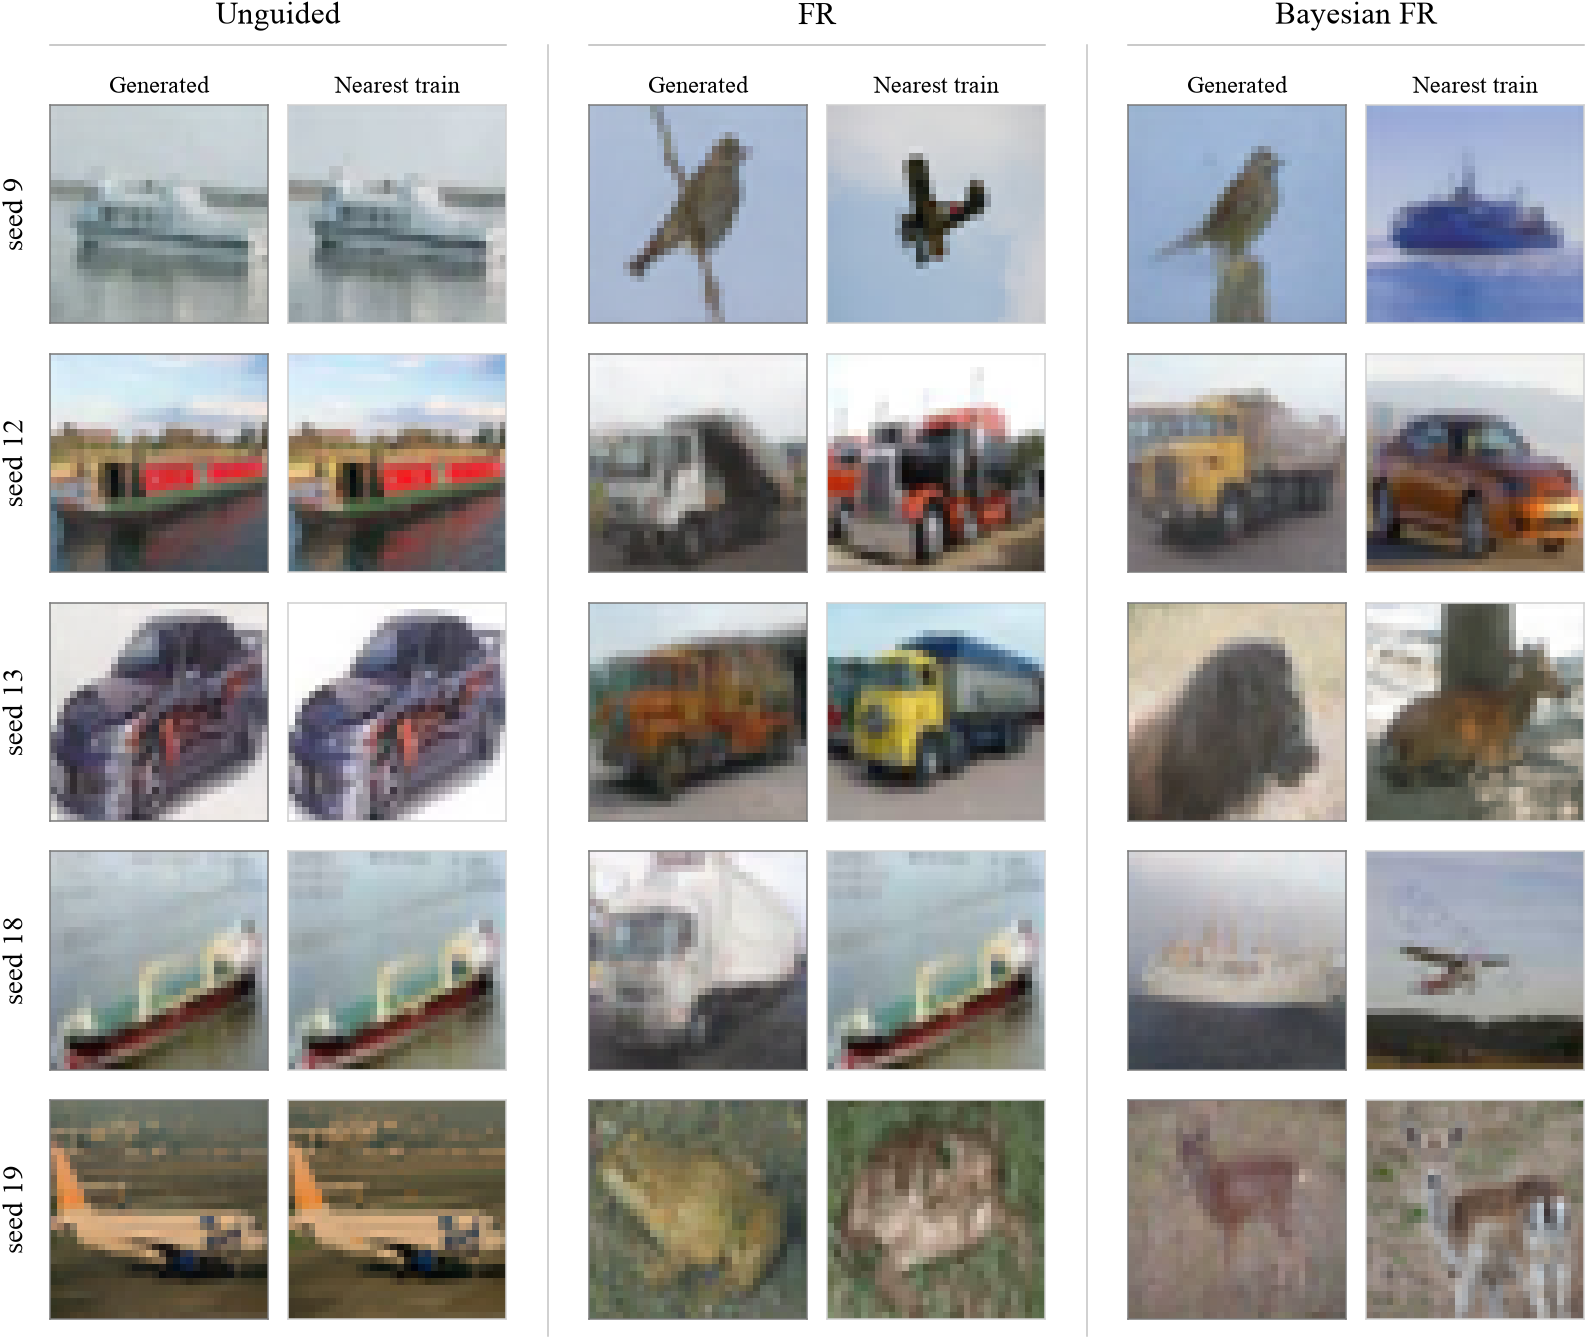

In [6]:
def to_img(x):
    """[1,3,32,32] or [3,32,32] in [-1,1] -> [32,32,3] in [0,1]."""
    t = x.squeeze(0) if x.dim() == 4 else x
    return ((t.permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()


SEEDS = config["seeds"]
BLOCKS = [(METHOD_LABELS[m], m) for m in METHODS]
COL_TITLES = ["Generated", "Nearest train"]

fig = plt.figure(figsize=(15.0, 13.0))
axes, blocks, block_rects = wsstyle.place_grid(
    fig, n_rows=len(SEEDS), block_sizes=[2] * len(BLOCKS),
    left=0.058, right=0.012, top=0.880, bottom=0.030,
    block_gap=0.050, panel_gap=0.012, row_gap=0.020)

for i, seed in enumerate(SEEDS):
    row = payload["rows"][seed]
    for b, (_, method) in enumerate(BLOCKS):
        cell = row["methods"][method]
        for j, img in enumerate([to_img(cell["x"]), to_img(cell["nn"])]):
            ax = blocks[b][i][j]
            ax.imshow(img, interpolation="nearest")
            wsstyle.strip_axes(ax)
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(1.0)
                sp.set_edgecolor("#7A7A7A" if j == 0 else "#D0D0D0")

for i, seed in enumerate(SEEDS):
    axes[i][0].set_ylabel(f"seed {seed}", labelpad=14)

for b in range(len(BLOCKS)):
    for ax, t in zip(blocks[b][0], COL_TITLES):
        ax.set_title(t, fontsize=mpl_fs - 3, pad=8)

rule_ys = []
for (label, _), block, rect in zip(BLOCKS, blocks, block_rects):
    flat = wsstyle.flatten(block)
    y = wsstyle.block_header(fig, flat, label, x_extent=rect, dy=0.052)
    wsstyle.header_rule(fig, rect, y - 0.010)
    rule_ys.append(y - 0.010)

GUTTER_COLOR = "#C4C4C4"
y_top = max(rule_ys)
y_bottom = min(ax.get_position().y0 for ax in wsstyle.flatten(axes)) - 0.012
for x in wsstyle.gutter_positions(block_rects):
    wsstyle.separator(fig, x, y_bottom, y_top, color=GUTTER_COLOR)

print(wsstyle.save(fig, "fig7"))